In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

# 04 — MeltPool Thermal Field Visualisation

The `MeltPool` object exposes two plot bridges: `.plot_side_view()` and `.plot_top_view()`.
These render the Rubenchik thermal field, overlaying the melt pool boundary (the isotherm at
the melting point). When parameters are scalar, a single plot is produced. When they are a 2D
grid, a full grid of subplots is automatically generated.

---

## Section 1 — Setup

We import the three core objects and load the **NiTi_Sheikh** material from the built-in
library. NiTi is a shape-memory alloy with relatively low thermal conductivity, which gives
well-defined, elongated melt pools — ideal for visualising the thermal field structure.

In [2]:
import numpy as np

from lpbf_maps import Material, ProcessParameters, MeltPool

# Load NiTi from the built-in material library
material = Material.from_library('NiTi_Sheikh')

print(f'Material : {material.name}')
print(f'Density  : {material.density} kg/m³')
print(f'T_melt   : {material.melting_temperature} K')
print(f'k        : {material.thermal_conductivity} W/(m·K)')
print(f'alpha    : {float(material.thermal_diffusivity):.3e} m²/s')

Material : NiTi
Density  : 6471.0 kg/m³
T_melt   : 1583.0 K
k        : 29.62 W/(m·K)
alpha    : 8.005e-06 m²/s


---

## Section 2 — Single Cross-Section: Side View

A **side view** renders the thermal field in the **XZ plane** (scanning direction × depth).
The X-axis runs along the scan direction (melt pool length), and the Z-axis points downward
into the substrate (melt pool depth).

The cyan dashed contour marks the **melting isotherm** (T = T_melt), which is the physical
melt pool boundary. All material inside this boundary is above liquidus.

### Optional arguments
- `save_path='niti_side.png'` — saves the figure to disk at 300 dpi.
- `remove_background=True` — masks temperatures below T_melt so only the molten region is
  visible (see Section 5).
- `resolution=100` — number of spatial grid points per axis for the field computation.

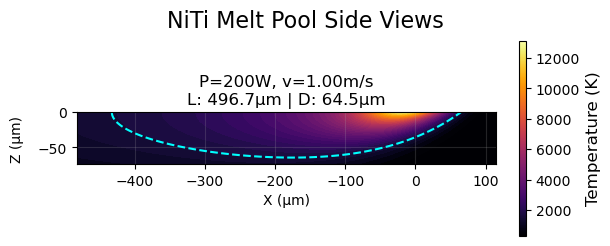

In [3]:
# Scalar process parameters: single operating point
params = ProcessParameters(
    laser_power=200.0,   # [W]
    scan_speed=1.0,      # [m/s]
    beam_radius=50e-6    # [m] — 50 µm 1/e² radius
)

# Build the MeltPool object — physics evaluation is deferred (lazy)
pool = MeltPool(material, params)

# Plot the side view (XZ plane)
# Returns the matplotlib (fig, axes) tuple for downstream customisation
fig, axes = pool.plot_side_view()

# Uncomment the line below to save to disk:
# fig, axes = pool.plot_side_view(save_path='niti_side.png')

---

## Section 3 — Single Cross-Section: Top View

A **top view** renders the thermal field in the **XY plane** (scanning direction × width).
This gives the bird’s-eye perspective looking straight down onto the powder bed surface
(z = 0).

The asymmetry in the X-direction (the trailing hot tail) is caused by the moving heat source:
ahead of the laser the material has not yet been heated, while behind it the heat has had
time to conduct outward.

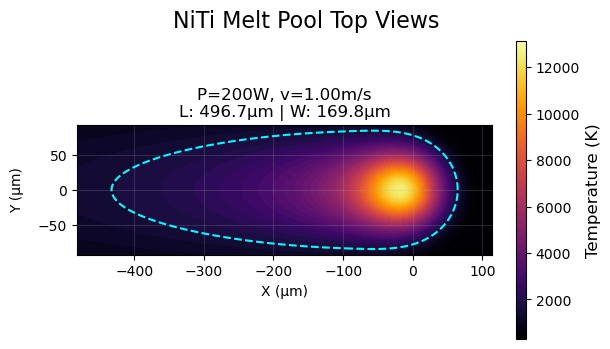

In [4]:
# Reuse the same scalar pool from Section 2
# Plot the top view (XY plane, at z = 0)
fig, axes = pool.plot_top_view()

# Uncomment to save:
# fig, axes = pool.plot_top_view(save_path='niti_top.png')

---

## Section 4 — Grid of Thermal Views (2D Parameter Sweep)

When `ProcessParameters` contains a **2D array** (laser_power rows × scan_speed columns),
`plot_side_view()` and `plot_top_view()` automatically produce a **matrix of subplots** —
one subplot per grid point.

Each subplot title shows the laser power (P) at that row, and the row label displays the
corresponding scan speed. The colourbar is shared across all subplots so relative temperatures
are directly comparable.

The grid below has **3 rows** (laser powers: 150, 200, 250 W) and **2 columns** (scan speeds:
0.8, 1.2 m/s), yielding a 3 × 2 subplot grid.

Parameter grid shape: (3, 2)  (rows=laser_power, cols=scan_speed)


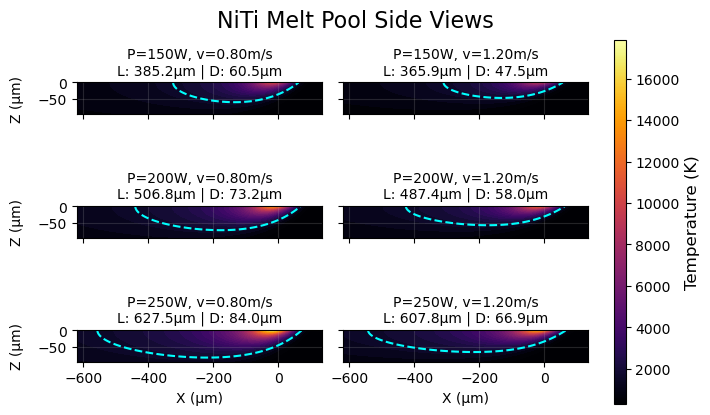

In [5]:
# --- Build a 2D parameter grid ---

# Column vector of laser powers  (shape: 3 x 1)
laser_powers = np.array([150.0, 200.0, 250.0])[:, np.newaxis]

# Row vector of scan speeds       (shape: 1 x 2)
scan_speeds = np.array([0.8, 1.2])[np.newaxis, :]

# NumPy broadcasting creates a 3x2 grid implicitly inside ProcessParameters
params_grid = ProcessParameters(
    laser_power=laser_powers,
    scan_speed=scan_speeds,
    beam_radius=50e-6          # scalar — broadcast to every grid point
)

print(f'Parameter grid shape: {params_grid.shape}  (rows=laser_power, cols=scan_speed)')

# Create the vectorised MeltPool
pool_grid = MeltPool(material, params_grid)

# plot_side_view() detects the 2D grid and produces a 3x2 subplot figure
# NOTE: This computes the thermal field at all 6 grid points — may take ~30 s
fig, axes = pool_grid.plot_side_view()

> **Reading the grid:**
> - Moving down the rows → increasing laser power → deeper, longer melt pool.
> - Moving across columns → increasing scan speed → shorter, narrower melt pool (less interaction time).
> - Colours are normalised to the global temperature peak across all subplots, making cross-comparisons valid.

---

## Section 5 — Removing the Background (Solid Region Masking)

By default, the thermal field is rendered across the entire spatial domain, with the substrate
and unmelted powder shown at their ambient temperatures. Passing `remove_background=True`
**masks all temperatures below T_melt**, so only the truly molten region is rendered.

This is particularly useful for:
- Visualising the exact melt pool shape without the surrounding thermal halo.
- Highlighting the heat-affected zone boundary vs the fusion boundary.
- Producing cleaner figures for publications.

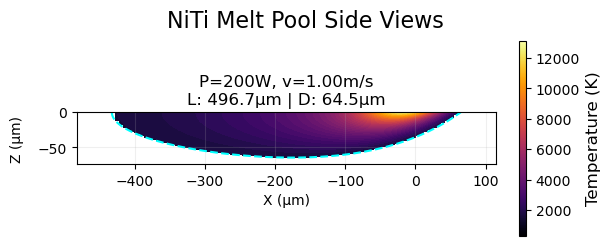

In [9]:
# Reuse the scalar pool from Section 2
# remove_background=True masks all T < T_melt — only the molten core is visible
fig, axes = pool.plot_side_view(remove_background=True)

# Uncomment to save the masked view:
# fig, axes = pool.plot_side_view(remove_background=True, save_path='niti_side_masked.png')

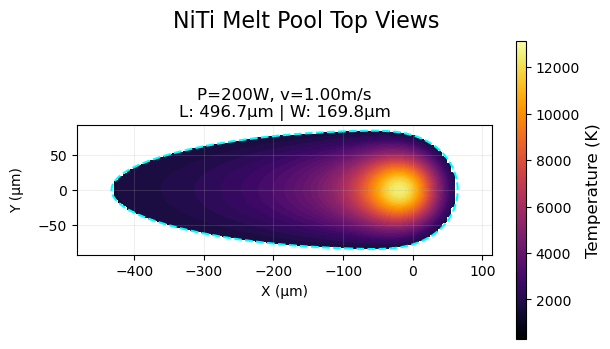

In [10]:
# The same masking is available for the top view
fig, axes = pool.plot_top_view(remove_background=True)

---

## Summary

| Method | Plane | X-axis | Y-axis | Use case |
|---|---|---|---|---|
| `pool.plot_side_view()` | XZ | Length (scan direction) | Depth | Penetration, keyhole risk |
| `pool.plot_top_view()` | XY | Length (scan direction) | Width | Track overlap, balling |

Both methods:
- Accept a `save_path` keyword to persist the figure.
- Accept `remove_background=True` to isolate the molten zone.
- Accept `resolution` (default 100) to trade off between computation time and field smoothness.
- Auto-detect whether parameters are scalar or 2D and adjust the layout accordingly.